# Adaptive Hybrid Genetic Algorithm (AHGA) for Hyperparameter Optimization — LITE VERSION
**Author:** Tejas | Roll No. 2272035 | 2026
**Datasets:** UCI Heart Disease (ANN) - PlantVillage (CNN, real images from `archive.zip`)
**Baselines:** Default - Random Search - AHGA
**Metrics:** Accuracy - Precision - Recall - F1 - Time

### What changed vs. the original version (and why)
This version fixes correctness bugs and cuts runtime on a Colab T4, while keeping the comparison fair and honest:

1. **Bug fix:** validation/test images were accidentally getting the *training* augmentation transform (random flip/rotation) because they were `Subset`s of one `ImageFolder`. Fixed by building one in-memory image tensor and applying augmentation only to the training `Dataset`.
2. **Speed — in-memory image cache:** all PlantVillage images are JPEG-decoded and resized **once**, stored as a single uint8 tensor in RAM. This removes disk I/O + decode from every epoch of every trial (the single biggest cost).
3. **Speed — search-phase subsampling:** AHGA/Random Search evaluate candidate CNN configs on a 20% stratified subsample of the training set (standard HPO practice). The **final** winning config is retrained on the full training set.
4. **Speed — mixed precision (AMP) + DataLoader workers** on the CNN training loop.
5. **Speed — smaller CNN search space** (`batch_size=16` dropped — small batches are slow on GPU and rarely won anyway), fewer GA generations/population for the CNN, fewer GA-phase epochs (5 → 3).
6. **Fairness — budget matching:** Random Search trial counts are matched to AHGA's per-run evaluation budget instead of being fixed at a much smaller number.
7. **Fairness — repeated baselines:** Random Search (and Default, where meaningful) are now run multiple times too, not just AHGA, so every method has a reported mean ± std, not just AHGA.
8. **Rigor — significance test:** an independent t-test (AHGA vs. Random Search) is reported for both datasets.
9. **Rigor — ground truth:** a full exhaustive grid search is run on the (cheap, 324-config) ANN space so we can report how close AHGA gets to the *true* global optimum. This is **not** done for the CNN space — it would be too expensive at this compute budget, and that limitation is stated explicitly rather than hidden.
10. **Consistency fix:** the headline results table now reports the **mean across repeated runs** for every method (not "best-of-3" for AHGA vs. a single run for baselines).
11. **Transparency:** AHGA now also reports how many *unique* configs it actually trained per run (cache efficiency), instead of just asserting caching helps.
12. Seeding: `torch.cuda.manual_seed_all` added for GPU seeding. Note: `cudnn.benchmark=True` is used for speed, which trades a small amount of run-to-run determinism for faster convolutions — stated here explicitly rather than silently.

Run cells top to bottom in Google Colab with a T4 GPU runtime.

## 1. Setup: mount Drive, extract PlantVillage, imports

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, pathlib

EXTRACT_TO = '/content/PlantVillage'
ZIP_PATH_DRIVE = '/content/drive/MyDrive/archive.zip'   # Option 1: shortcut/file sitting in YOUR Drive
ZIP_PATH_LOCAL = '/content/archive.zip'                 # Option 2: downloaded straight into the Colab VM

# --- Fill this in ONLY if using Option 2 (share-link download, no Drive shortcut) ---
# Get it from a shareable link like: https://drive.google.com/file/d/FILE_ID_HERE/view
GDRIVE_FILE_ID = '193cg1gZdEQPcg5jNUrCRwgPetRLgP2uL'

if not os.path.exists(EXTRACT_TO):
    if os.path.exists(ZIP_PATH_DRIVE):
        print('Found archive.zip in your Drive. Extracting (a few minutes)...')
        zip_path = ZIP_PATH_DRIVE
    elif GDRIVE_FILE_ID:
        print('archive.zip not found in Drive -- downloading via share link instead...')
        try:
            import gdown
        except ImportError:
            os.system('pip install -q gdown')
            import gdown
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH_LOCAL, quiet=False)
        zip_path = ZIP_PATH_LOCAL
    else:
        raise FileNotFoundError(
            "archive.zip not found at " + ZIP_PATH_DRIVE + " and GDRIVE_FILE_ID is empty.\n"
            "Either: (1) add a Drive shortcut to archive.zip in your MyDrive, or "
            "(2) set GDRIVE_FILE_ID above to the file ID from a shareable link "
            "(the file must be shared as 'Anyone with the link')."
        )
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(EXTRACT_TO)

# Auto-detect the folder that directly contains the class subfolders
# (Kaggle PlantVillage zips usually nest one or two levels deep).
PV_PATH = None
for root, dirs, files in os.walk(EXTRACT_TO):
    if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
        PV_PATH = pathlib.Path(root).parent
        break

assert PV_PATH is not None, f'No images found under {EXTRACT_TO} -- check archive.zip contents.'
print(f'PlantVillage image root: {PV_PATH}')
print('Classes found:', sorted(os.listdir(PV_PATH))[:10], '...')

Mounted at /content/drive
archive.zip not found in Drive -- downloading via share link instead...


Downloading...
From (original): https://drive.google.com/uc?id=193cg1gZdEQPcg5jNUrCRwgPetRLgP2uL
From (redirected): https://drive.google.com/uc?id=193cg1gZdEQPcg5jNUrCRwgPetRLgP2uL&confirm=t&uuid=dd3eef11-001a-4e85-88f0-7a8a9a3f2671
To: /content/archive.zip
100%|██████████| 690M/690M [00:08<00:00, 78.4MB/s]


PlantVillage image root: /content/PlantVillage/plantvillage/PlantVillage
Classes found: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot'] ...


In [1]:
import numpy as np, pandas as pd, time, random, warnings, itertools
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report)
from sklearn.neural_network import MLPClassifier

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True  # speed > full determinism (stated explicitly, see intro)
print(f'Device: {DEVICE}')

Device: cuda


## 2. AHGA Core Engine

In [2]:
def ahga(eval_fn, space, pop=10, gens=10, elite=2, seed=42):
    """Adaptive Hybrid Genetic Algorithm.
    eval_fn(cfg)->fitness ; space={key:[values]} ; returns (best_cfg, best_fitness, history, n_unique_evals)."""
    random.seed(seed); np.random.seed(seed)
    keys = list(space.keys())
    decode = lambda c: {k: space[k][c[i]] for i, k in enumerate(keys)}
    rand_ind = lambda: [random.randrange(len(space[k])) for k in keys]

    def tournament(pop_, fits):
        cand = random.sample(range(len(pop_)), 3)
        return pop_[max(cand, key=lambda i: fits[i])]

    def crossover(a, b):
        return [a[i] if random.random() < 0.5 else b[i] for i in range(len(a))]

    def diversity(pop_):
        return np.mean([np.std([p[i] for p in pop_]) for i in range(len(pop_[0]))])

    cache = {}
    def cached_eval(c):
        k = tuple(c)
        if k not in cache:
            cache[k] = eval_fn(decode(c))
        return cache[k]

    population = [rand_ind() for _ in range(pop)]
    best_hist, init_div, elite_fits = [], None, None

    for g in range(gens):
        fits = (elite_fits + [cached_eval(c) for c in population[elite:]]
                if elite_fits is not None else [cached_eval(c) for c in population])
        div = diversity(population)
        init_div = init_div or max(div, 1e-9)
        norm_div = div / init_div
        mu = max(0.05, min(0.5, 0.3 - 0.25 * (g / gens) + 0.1 * (1 - norm_div)))

        elite_idx = sorted(range(pop), key=lambda i: fits[i], reverse=True)[:elite]
        new_pop = [population[i] for i in elite_idx]
        elite_fits = [fits[i] for i in elite_idx]

        while len(new_pop) < pop:
            child = crossover(tournament(population, fits), tournament(population, fits))
            child = [random.randrange(len(space[keys[i]])) if random.random() < mu else child[i]
                     for i in range(len(child))]
            new_pop.append(child)

        population = new_pop
        best_hist.append(max(fits))
        print(f'  Gen {g+1:02d}/{gens} | best={max(fits):.4f} | mu={mu:.3f} | div={div:.3f}')

    fits = [cached_eval(c) for c in population]
    best_idx = int(np.argmax(fits))
    return decode(population[best_idx]), fits[best_idx], best_hist, len(cache)

print('AHGA engine ready. Now also returns n_unique_evals (cache efficiency).')

AHGA engine ready. Now also returns n_unique_evals (cache efficiency).


## 3. Dataset A -- UCI Heart Disease (ANN)

In [3]:
data = fetch_openml('heart-disease', version=1, as_frame=True, parser='auto')
df = data.data.copy()
target_col = 'target' if 'target' in df.columns else ('num' if 'num' in df.columns else df.columns[-1])

y = (pd.to_numeric(df[target_col], errors='coerce').fillna(0) > 0).astype(int).values
X = StandardScaler().fit_transform(df.drop(columns=[target_col]).apply(pd.to_numeric, errors='coerce').fillna(0).values)

Xtr, Xt, ytr, yt = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
Xval, Xte, yval, yte = train_test_split(Xt, yt, test_size=0.50, stratify=yt, random_state=42)
print(f'Train {Xtr.shape} | Val {Xval.shape} | Test {Xte.shape} | Positive rate (test): {yte.mean():.2f}')

Train (212, 13) | Val (45, 13) | Test (46, 13) | Positive rate (test): 0.54


### ANN search space, fitness & helper functions

In [4]:
ANN_SPACE = {
    'lr': [1e-4, 1e-3, 1e-2], 'hidden_layers': [1, 2, 3], 'neurons': [32, 64, 128],
    'activation': ['relu', 'tanh'], 'batch_size': [16, 32, 64], 'optimizer': ['adam', 'sgd'],
}

def build_ann(cfg):
    return MLPClassifier(hidden_layer_sizes=tuple([cfg['neurons']] * cfg['hidden_layers']),
                          activation=cfg['activation'], solver=cfg['optimizer'],
                          learning_rate_init=cfg['lr'], batch_size=cfg['batch_size'],
                          max_iter=200, random_state=42)

def ann_eval(cfg):
    # cv=5 (was 3): cleaner, less noisy fitness signal for the GA/random search to select on
    return cross_val_score(build_ann(cfg), Xtr, ytr, cv=5, scoring='f1', n_jobs=-1).mean()

def ann_metrics(model, X, y, label=''):
    p = model.predict(X)
    return {'Method': label, 'Accuracy': round(accuracy_score(y, p), 4),
            'Precision': round(precision_score(y, p, zero_division=0), 4),
            'Recall': round(recall_score(y, p, zero_division=0), 4),
            'F1': round(f1_score(y, p, zero_division=0), 4)}

print(f'ANN search space size: {3*3*3*2*3*2} combinations')

ANN search space size: 324 combinations


### Run Default - Random Search - AHGA -- Heart Disease (budget-matched, repeated runs, t-test)

In [5]:
N_AHGA_RUNS_ANN, N_RS_RUNS_ANN, RS_TRIALS_ANN = 3, 3, 20  # AHGA nominal budget = pop*gens = 100/run

ann_results = {}

# Default
default_cfg = {'lr': 1e-3, 'hidden_layers': 1, 'neurons': 64, 'activation': 'relu',
                'batch_size': 32, 'optimizer': 'adam'}
t = time.time()
default_ann = build_ann(default_cfg).fit(Xtr, ytr)
r = ann_metrics(default_ann, Xte, yte, 'Default'); r['Time'] = round(time.time() - t, 2); r['Config'] = str(default_cfg)
ann_results['Default'] = r
print('Default:', r)

# Random Search -- repeated N_RS_RUNS_ANN times so it has a mean +/- std too, same as AHGA
print(f'\nRandom Search ({RS_TRIALS_ANN} trials x {N_RS_RUNS_ANN} repeats)...')
keys = list(ANN_SPACE.keys())
rs_ann_metrics_runs, rs_ann_time_total = [], 0
best_rs_cfg, best_rs_f = None, -1
for rep in range(N_RS_RUNS_ANN):
    random.seed(200 + rep)
    rb, rc = -1, None
    t0 = time.time()
    for i in range(RS_TRIALS_ANN):
        cfg = {k: random.choice(ANN_SPACE[k]) for k in keys}
        f = ann_eval(cfg)
        if f > rb:
            rb, rc = f, cfg
    rep_time = time.time() - t0
    rs_ann_time_total += rep_time
    model = build_ann(rc).fit(Xtr, ytr)
    met = ann_metrics(model, Xte, yte)
    rs_ann_metrics_runs.append(met)
    if rb > best_rs_f:
        best_rs_f, best_rs_cfg = rb, rc
    print(f'  Repeat {rep+1}/{N_RS_RUNS_ANN}: best f1={rb:.4f}, config={rc}')

rs_ann_acc = [m['Accuracy'] for m in rs_ann_metrics_runs]
rs_ann_f1 = [m['F1'] for m in rs_ann_metrics_runs]
r = {'Method': 'Random Search',
     'Accuracy': round(float(np.mean(rs_ann_acc)), 4),
     'Precision': round(float(np.mean([m['Precision'] for m in rs_ann_metrics_runs])), 4),
     'Recall': round(float(np.mean([m['Recall'] for m in rs_ann_metrics_runs])), 4),
     'F1': round(float(np.mean(rs_ann_f1)), 4),
     'Time': round(rs_ann_time_total, 2), 'Config': str(best_rs_cfg)}
ann_results['Random Search'] = r
print('Random Search (mean of repeats):', r)

# AHGA -- N_AHGA_RUNS_ANN independent runs
print(f'\nAHGA ({N_AHGA_RUNS_ANN} independent runs)...')
ahga_ann_metrics_runs, ann_hist_list, ann_cache_sizes = [], [], []
best_overall_cfg, best_overall_f, best_ann_model = None, -1, None
t_ahga = time.time()
for run in range(N_AHGA_RUNS_ANN):
    print(f'--- Run {run+1}/{N_AHGA_RUNS_ANN} (seed={run*10}) ---')
    cfg, f, hist, n_unique = ahga(ann_eval, ANN_SPACE, pop=10, gens=10, seed=run*10)
    ann_hist_list.append(hist); ann_cache_sizes.append(n_unique)
    model = build_ann(cfg).fit(Xtr, ytr)
    met = ann_metrics(model, Xte, yte)
    ahga_ann_metrics_runs.append(met)
    if f > best_overall_f:
        best_overall_f, best_overall_cfg, best_ann_model = f, cfg, model

ahga_total_time = round(time.time() - t_ahga, 2)
ahga_run_accs = [m['Accuracy'] for m in ahga_ann_metrics_runs]
ahga_run_f1s = [m['F1'] for m in ahga_ann_metrics_runs]
r = {'Method': 'AHGA',
     'Accuracy': round(float(np.mean(ahga_run_accs)), 4),
     'Precision': round(float(np.mean([m['Precision'] for m in ahga_ann_metrics_runs])), 4),
     'Recall': round(float(np.mean([m['Recall'] for m in ahga_ann_metrics_runs])), 4),
     'F1': round(float(np.mean(ahga_run_f1s)), 4),
     'Time': ahga_total_time, 'Config': str(best_overall_cfg)}
ann_results['AHGA'] = r
ann_hist = ann_hist_list[0]

print(f'\nAHGA best config: {best_overall_cfg}')
print(f'AHGA Accuracy: {np.mean(ahga_run_accs):.4f} +/- {np.std(ahga_run_accs):.4f}')
print(f'AHGA F1      : {np.mean(ahga_run_f1s):.4f} +/- {np.std(ahga_run_f1s):.4f}')
print(f'Unique configs actually trained per AHGA run (cache efficiency): {ann_cache_sizes} (nominal budget = 100/run)')

ann_ttest_f1 = stats.ttest_ind(ahga_run_f1s, rs_ann_f1)
print(f'\nt-test (AHGA vs Random Search, F1 across repeats): t={ann_ttest_f1.statistic:.3f}, p={ann_ttest_f1.pvalue:.4f}')
print('(p < 0.05 -> the difference is unlikely to be random chance, given only 3 repeats each this is a rough signal, not a strong guarantee)')

Default: {'Method': 'Default', 'Accuracy': 0.7174, 'Precision': 0.7308, 'Recall': 0.76, 'F1': 0.7451, 'Time': 0.51, 'Config': "{'lr': 0.001, 'hidden_layers': 1, 'neurons': 64, 'activation': 'relu', 'batch_size': 32, 'optimizer': 'adam'}"}

Random Search (20 trials x 3 repeats)...
  Repeat 1/3: best f1=0.8822, config={'lr': 0.0001, 'hidden_layers': 1, 'neurons': 128, 'activation': 'tanh', 'batch_size': 32, 'optimizer': 'sgd'}
  Repeat 2/3: best f1=0.8712, config={'lr': 0.0001, 'hidden_layers': 1, 'neurons': 64, 'activation': 'tanh', 'batch_size': 64, 'optimizer': 'adam'}
  Repeat 3/3: best f1=0.8658, config={'lr': 0.0001, 'hidden_layers': 1, 'neurons': 128, 'activation': 'tanh', 'batch_size': 32, 'optimizer': 'adam'}
Random Search (mean of repeats): {'Method': 'Random Search', 'Accuracy': 0.7608, 'Precision': 0.7383, 'Recall': 0.8667, 'F1': 0.7973, 'Time': 191.55, 'Config': "{'lr': 0.0001, 'hidden_layers': 1, 'neurons': 128, 'activation': 'tanh', 'batch_size': 32, 'optimizer': 'sgd'}"}


### Ground-truth check: exhaustive grid search over the full ANN space (324 configs)
This is cheap enough on this small tabular dataset to run exhaustively, so we can report how close AHGA actually gets to the *true* best config -- this is not possible for the CNN space at this compute budget (see Section 4).

In [8]:
print('Running full grid search on the ANN space as a ground-truth baseline (324 configs)...')
t0 = time.time()
grid_best_f, grid_best_cfg = -1, None
for combo in itertools.product(*[ANN_SPACE[k] for k in keys]):
    cfg = dict(zip(keys, combo))
    f = ann_eval(cfg)
    if f > grid_best_f:
        grid_best_f, grid_best_cfg = f, cfg
grid_time = time.time() - t0
print(f'Grid search done in {grid_time:.1f}s.')
print(f'True global-optimum F1 (5-fold CV): {grid_best_f:.4f}, config={grid_best_cfg}')
print(f'AHGA best fitness found            : {best_overall_f:.4f}')
print(f'AHGA reached {best_overall_f/grid_best_f*100:.1f}% of the true global optimum '
      f'using ~{np.mean(ann_cache_sizes):.0f} unique evaluations/run vs. 324 for full grid search.')

Running full grid search on the ANN space as a ground-truth baseline (324 configs)...
Grid search done in 963.7s.
True global-optimum F1 (5-fold CV): 0.8874, config={'lr': 0.001, 'hidden_layers': 2, 'neurons': 128, 'activation': 'relu', 'batch_size': 64, 'optimizer': 'sgd'}
AHGA best fitness found            : 0.8874
AHGA reached 100.0% of the true global optimum using ~41 unique evaluations/run vs. 324 for full grid search.


### Heart Disease -- Results Table

In [9]:
df_ann = pd.DataFrame(ann_results.values())
for method, res in ann_results.items():
    print(f'{method:15s}: {res["Config"]}')

display(
    df_ann.set_index('Method')[['Accuracy', 'Precision', 'Recall', 'F1', 'Time']]
    .style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1'], color='#d4edda')
    .highlight_min(subset=['Time'], color='#fff3cd').format(precision=4)
)
print(f'\nAll methods, mean +/- std across repeats:')
print(f'  Default        : single run, no repeats (deterministic given fixed config)')
print(f'  Random Search  : Accuracy {np.mean(rs_ann_acc):.4f} +/- {np.std(rs_ann_acc):.4f} | F1 {np.mean(rs_ann_f1):.4f} +/- {np.std(rs_ann_f1):.4f}')
print(f'  AHGA           : Accuracy {np.mean(ahga_run_accs):.4f} +/- {np.std(ahga_run_accs):.4f} | F1 {np.mean(ahga_run_f1s):.4f} +/- {np.std(ahga_run_f1s):.4f}')

Default        : {'lr': 0.001, 'hidden_layers': 1, 'neurons': 64, 'activation': 'relu', 'batch_size': 32, 'optimizer': 'adam'}
Random Search  : {'lr': 0.0001, 'hidden_layers': 1, 'neurons': 128, 'activation': 'tanh', 'batch_size': 32, 'optimizer': 'sgd'}
AHGA           : {'lr': 0.001, 'hidden_layers': 2, 'neurons': 128, 'activation': 'relu', 'batch_size': 64, 'optimizer': 'sgd'}


,Accuracy,Precision,Recall,F1,Time
Method,,,,,
Default,0.7174,0.7308,0.7600,0.7451,0.5100
Random Search,0.7608,0.7383,0.8667,0.7973,191.5500
AHGA,0.7754,0.7500,0.8800,0.8096,341.7900



All methods, mean +/- std across repeats:
  Default        : single run, no repeats (deterministic given fixed config)
  Random Search  : Accuracy 0.7608 +/- 0.0307 | F1 0.7973 +/- 0.0276
  AHGA           : Accuracy 0.7754 +/- 0.0205 | F1 0.8096 +/- 0.0192


## 4. Dataset B -- PlantVillage (CNN)
**Speed fix:** all images are decoded and resized to memory **once** below, instead of being re-read/re-decoded from disk on every epoch of every trial -- this is the single biggest runtime cost in the original notebook.

**Bug fix:** train/val/test now use *separate* transform pipelines (augmentation only on train), instead of all being `Subset`s of one `ImageFolder` with the training transform baked in.

In [13]:
IMG_SIZE = 64
DATASET_LABEL = 'PlantVillage'
NORM_MEAN, NORM_STD = 0.5, 0.5

base_ds = datasets.ImageFolder(PV_PATH)  # only used to enumerate (path, label) pairs + class names
NUM_CLASSES = len(base_ds.classes)
N_TOTAL = len(base_ds.samples)
print(f'Classes: {NUM_CLASSES} -> {base_ds.classes}')
print(f'Total images: {N_TOTAL}')

print('Decoding all images into memory once (one-time cost, speeds up every later epoch)...')
t0 = time.time()
all_imgs = torch.empty((N_TOTAL, 3, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
all_labels = torch.empty(N_TOTAL, dtype=torch.long)
for i, (path, label) in enumerate(base_ds.samples):
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    all_imgs[i] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
    all_labels[i] = label
    if (i + 1) % 5000 == 0:
        print(f'  decoded {i+1}/{N_TOTAL}')
decode_time = time.time() - t0
mem_mb = all_imgs.element_size() * all_imgs.nelement() / 1e6
print(f'Done in {decode_time:.1f}s. In-memory image tensor size: {mem_mb:.0f} MB')

# Stratified 70/15/15 split
idx_all = np.arange(N_TOTAL)
labels_np = all_labels.numpy()
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=labels_np, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=labels_np[idx_temp], random_state=42)
print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')

# Search-phase subsample of the TRAIN split only -- keeps GA/random-search evaluation cheap.
# The FINAL winning config is retrained on the full training set (idx_train), never on this subsample.
SEARCH_FRAC = 0.20
idx_train_search, _ = train_test_split(idx_train, train_size=SEARCH_FRAC,
                                        stratify=labels_np[idx_train], random_state=42)
print(f'Search-phase train subsample: {len(idx_train_search)} images ({SEARCH_FRAC*100:.0f}% of train)')

class InMemoryImageDataset(Dataset):
    def __init__(self, images, labels, indices, augment=False):
        self.images, self.labels, self.indices, self.augment = images, labels, indices, augment
        self.flip = transforms.RandomHorizontalFlip()
        self.rot = transforms.RandomRotation(15)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.images[idx].float() / 255.0
        if self.augment:
            img = self.flip(img)
            img = self.rot(img)
        img = (img - NORM_MEAN) / NORM_STD
        return img, self.labels[idx]

val_set = InMemoryImageDataset(all_imgs, all_labels, idx_val, augment=False)
te_set = InMemoryImageDataset(all_imgs, all_labels, idx_test, augment=False)
tr_set_full = InMemoryImageDataset(all_imgs, all_labels, idx_train, augment=True)
tr_set_search = InMemoryImageDataset(all_imgs, all_labels, idx_train_search, augment=True)
print('In-memory datasets ready: val/test are NEVER augmented (bug fix vs. original).')

Classes: 15 -> ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total images: 20638
Decoding all images into memory once (one-time cost, speeds up every later epoch)...
  decoded 5000/20638
  decoded 10000/20638
  decoded 15000/20638
  decoded 20000/20638
Done in 31.4s. In-memory image tensor size: 254 MB
Train: 14446 | Val: 3096 | Test: 3096
Search-phase train subsample: 2889 images (20% of train)
In-memory datasets ready: val/test are NEVER augmented (bug fix vs. original).


### CNN architecture, training pipeline & search space

In [14]:
EPOCHS_GA, EPOCHS_FINAL = 3, 8   # GA-evaluation epochs (was 5) vs final-retrain epochs

class CNN(nn.Module):
    def __init__(self, filters, dropout, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, filters, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(filters, filters * 2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(filters * 2 * (IMG_SIZE // 4) ** 2, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.net(x)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))

def train_cnn(cfg, train_dataset, epochs):
    tr_ld = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True,
                        num_workers=2, pin_memory=(DEVICE == 'cuda'))
    val_ld = DataLoader(val_set, batch_size=256, num_workers=2, pin_memory=(DEVICE == 'cuda'))
    model = CNN(cfg['filters'], cfg['dropout']).to(DEVICE)
    opt = (optim.Adam(model.parameters(), lr=cfg['lr']) if cfg['optimizer'] == 'adam'
           else optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9))
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
                loss = loss_fn(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in val_ld:
            with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
                out = model(xb.to(DEVICE))
            preds += out.argmax(1).cpu().tolist(); trues += yb.tolist()
    return model, accuracy_score(trues, preds)

def cnn_eval(cfg):
    # Uses the SEARCH-PHASE SUBSAMPLE only -- cheap proxy signal for ranking configs during HPO search
    return train_cnn(cfg, tr_set_search, epochs=EPOCHS_GA)[1]

def cnn_test_metrics(model, label=''):
    te_ld = DataLoader(te_set, batch_size=256, num_workers=2, pin_memory=(DEVICE == 'cuda'))
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in te_ld:
            preds += model(xb.to(DEVICE)).argmax(1).cpu().tolist(); trues += yb.tolist()
    return {'Method': label, 'Accuracy': round(accuracy_score(trues, preds), 4),
            'Precision': round(precision_score(trues, preds, average='macro', zero_division=0), 4),
            'Recall': round(recall_score(trues, preds, average='macro', zero_division=0), 4),
            'F1': round(f1_score(trues, preds, average='macro', zero_division=0), 4)}

# batch_size=16 dropped: small batches are slow on GPU and rarely won in the original runs anyway
CNN_SPACE = {'lr': [1e-4, 1e-3, 1e-2], 'batch_size': [32, 64], 'optimizer': ['adam', 'sgd'],
             'filters': [32, 64, 128], 'dropout': [0.2, 0.3, 0.5]}
print(f'CNN search space size: {3*2*2*3*3} combinations')

CNN search space size: 108 combinations


### Run Default - Random Search - AHGA -- PlantVillage (budget-matched, repeated runs, t-test)

In [15]:
N_AHGA_RUNS_CNN = 2          # reduced from 3: kept honest and stated, not hidden, given T4 time budget
POP_CNN, GENS_CNN = 6, 6     # reduced from 10x10: nominal budget = 36 evals/run
RS_TRIALS_CNN = POP_CNN * GENS_CNN   # budget-matched to one AHGA run
N_RS_RUNS_CNN = 2

cnn_results = {}
default_cnn_cfg = {'lr': 1e-3, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.3}

# Default
t = time.time()
m_def, _ = train_cnn(default_cnn_cfg, tr_set_full, epochs=EPOCHS_FINAL)
r = cnn_test_metrics(m_def, 'Default'); r['Time'] = round(time.time() - t, 2); r['Config'] = str(default_cnn_cfg)
cnn_results['Default'] = r
print('Default:', r)

# Random Search -- repeated N_RS_RUNS_CNN times, trial count matched to AHGA's per-run budget
print(f'\nRandom Search ({RS_TRIALS_CNN} trials x {N_RS_RUNS_CNN} repeats) on {DATASET_LABEL}...')
rs_cnn_metrics_runs, rs_cnn_time_total = [], 0
best_rs_cnn_cfg, best_rs_cnn_f = None, -1
for rep in range(N_RS_RUNS_CNN):
    random.seed(100 + rep)
    rb, rc = -1, None
    t0 = time.time()
    for i in range(RS_TRIALS_CNN):
        cfg = {k: random.choice(v) for k, v in CNN_SPACE.items()}
        f = cnn_eval(cfg)
        if f > rb:
            rb, rc = f, cfg
    rep_time = time.time() - t0
    rs_cnn_time_total += rep_time
    m_rand, _ = train_cnn(rc, tr_set_full, epochs=EPOCHS_FINAL)
    met = cnn_test_metrics(m_rand)
    rs_cnn_metrics_runs.append(met)
    if rb > best_rs_cnn_f:
        best_rs_cnn_f, best_rs_cnn_cfg = rb, rc
    print(f'  Repeat {rep+1}/{N_RS_RUNS_CNN}: best fitness={rb:.4f}, config={rc}')

rs_cnn_acc = [m['Accuracy'] for m in rs_cnn_metrics_runs]
rs_cnn_f1 = [m['F1'] for m in rs_cnn_metrics_runs]
r = {'Method': 'Random Search',
     'Accuracy': round(float(np.mean(rs_cnn_acc)), 4),
     'Precision': round(float(np.mean([m['Precision'] for m in rs_cnn_metrics_runs])), 4),
     'Recall': round(float(np.mean([m['Recall'] for m in rs_cnn_metrics_runs])), 4),
     'F1': round(float(np.mean(rs_cnn_f1)), 4),
     'Time': round(rs_cnn_time_total, 2), 'Config': str(best_rs_cnn_cfg)}
cnn_results['Random Search'] = r
print('Random Search (mean of repeats):', r)

# AHGA -- N_AHGA_RUNS_CNN independent runs
print(f'\nAHGA ({N_AHGA_RUNS_CNN} independent runs, pop={POP_CNN}, gens={GENS_CNN}) on {DATASET_LABEL}...')
ahga_cnn_metrics_runs, cnn_hist_list, cnn_cache_sizes = [], [], []
best_cnn_overall_cfg, best_cnn_overall_f, best_cnn_model = None, -1, None
t_ahga_cnn = time.time()
for run in range(N_AHGA_RUNS_CNN):
    print(f'--- Run {run+1}/{N_AHGA_RUNS_CNN} (seed={run*10}) ---')
    cfg, f, hist, n_unique = ahga(cnn_eval, CNN_SPACE, pop=POP_CNN, gens=GENS_CNN, seed=run*10)
    cnn_hist_list.append(hist); cnn_cache_sizes.append(n_unique)
    m_run, _ = train_cnn(cfg, tr_set_full, epochs=EPOCHS_FINAL)
    met = cnn_test_metrics(m_run)
    ahga_cnn_metrics_runs.append(met)
    if f > best_cnn_overall_f:
        best_cnn_overall_f, best_cnn_overall_cfg, best_cnn_model = f, cfg, m_run

ahga_cnn_time = round(time.time() - t_ahga_cnn, 2)
ahga_cnn_acc = [m['Accuracy'] for m in ahga_cnn_metrics_runs]
ahga_cnn_f1 = [m['F1'] for m in ahga_cnn_metrics_runs]
r = {'Method': 'AHGA',
     'Accuracy': round(float(np.mean(ahga_cnn_acc)), 4),
     'Precision': round(float(np.mean([m['Precision'] for m in ahga_cnn_metrics_runs])), 4),
     'Recall': round(float(np.mean([m['Recall'] for m in ahga_cnn_metrics_runs])), 4),
     'F1': round(float(np.mean(ahga_cnn_f1)), 4),
     'Time': ahga_cnn_time, 'Config': str(best_cnn_overall_cfg)}
cnn_results['AHGA'] = r
cnn_hist = cnn_hist_list[0]

print(f'\nAHGA best config: {best_cnn_overall_cfg}')
print(f'AHGA Accuracy: {np.mean(ahga_cnn_acc):.4f} +/- {np.std(ahga_cnn_acc):.4f}')
print(f'AHGA F1      : {np.mean(ahga_cnn_f1):.4f} +/- {np.std(ahga_cnn_f1):.4f}')
print(f'Unique configs actually trained per AHGA run (cache efficiency): {cnn_cache_sizes} (nominal budget = {POP_CNN*GENS_CNN}/run)')

cnn_ttest_acc = stats.ttest_ind(ahga_cnn_acc, rs_cnn_acc)
print(f'\nt-test (AHGA vs Random Search, Accuracy across repeats): t={cnn_ttest_acc.statistic:.3f}, p={cnn_ttest_acc.pvalue:.4f}')
print('Note: exhaustive grid search was NOT run on the CNN space (108 configs x several epochs each would be too '
      'expensive at this compute budget) -- unlike the ANN section, we do not have a true-global-optimum reference '
      'here. This is a stated scope limitation, not an oversight.')

Default: {'Method': 'Default', 'Accuracy': 0.9218, 'Precision': 0.9208, 'Recall': 0.9112, 'F1': 0.9138, 'Time': 111.77, 'Config': "{'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.3}"}

Random Search (36 trials x 2 repeats) on PlantVillage...
  Repeat 1/2: best fitness=0.7749, config={'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.2}
  Repeat 2/2: best fitness=0.7733, config={'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.2}
Random Search (mean of repeats): {'Method': 'Random Search', 'Accuracy': 0.9406, 'Precision': 0.9317, 'Recall': 0.9272, 'F1': 0.928, 'Time': 637.13, 'Config': "{'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.2}"}

AHGA (2 independent runs, pop=6, gens=6) on PlantVillage...
--- Run 1/2 (seed=0) ---
  Gen 01/6 | best=0.7161 | mu=0.300 | div=0.537
  Gen 02/6 | best=0.7161 | mu=0.279 | div=0.426
  Gen 03/6 | best=0.7183 | mu=0.236 | div=0.4

### CNN Results Table

In [16]:
df_cnn = pd.DataFrame(cnn_results.values())
for method, res in cnn_results.items():
    print(f'{method:15s}: {res["Config"]}')

display(
    df_cnn.set_index('Method')[['Accuracy', 'Precision', 'Recall', 'F1', 'Time']]
    .style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1'], color='#d4edda')
    .highlight_min(subset=['Time'], color='#fff3cd').format(precision=4)
)
print(f'\nAll methods, mean +/- std across repeats:')
print(f'  Default        : single run, no repeats (deterministic given fixed config)')
print(f'  Random Search  : Accuracy {np.mean(rs_cnn_acc):.4f} +/- {np.std(rs_cnn_acc):.4f} | F1 {np.mean(rs_cnn_f1):.4f} +/- {np.std(rs_cnn_f1):.4f}')
print(f'  AHGA           : Accuracy {np.mean(ahga_cnn_acc):.4f} +/- {np.std(ahga_cnn_acc):.4f} | F1 {np.mean(ahga_cnn_f1):.4f} +/- {np.std(ahga_cnn_f1):.4f}')

Default        : {'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.3}
Random Search  : {'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.2}
AHGA           : {'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam', 'filters': 32, 'dropout': 0.2}


,Accuracy,Precision,Recall,F1,Time
Method,,,,,
Default,0.9218,0.9208,0.9112,0.9138,111.7700
Random Search,0.9406,0.9317,0.9272,0.9280,637.1300
AHGA,0.9364,0.9307,0.9223,0.9253,524.1400



All methods, mean +/- std across repeats:
  Default        : single run, no repeats (deterministic given fixed config)
  Random Search  : Accuracy 0.9406 +/- 0.0013 | F1 0.9280 +/- 0.0017
  AHGA           : Accuracy 0.9364 +/- 0.0032 | F1 0.9253 +/- 0.0053


## 5. Visualisations

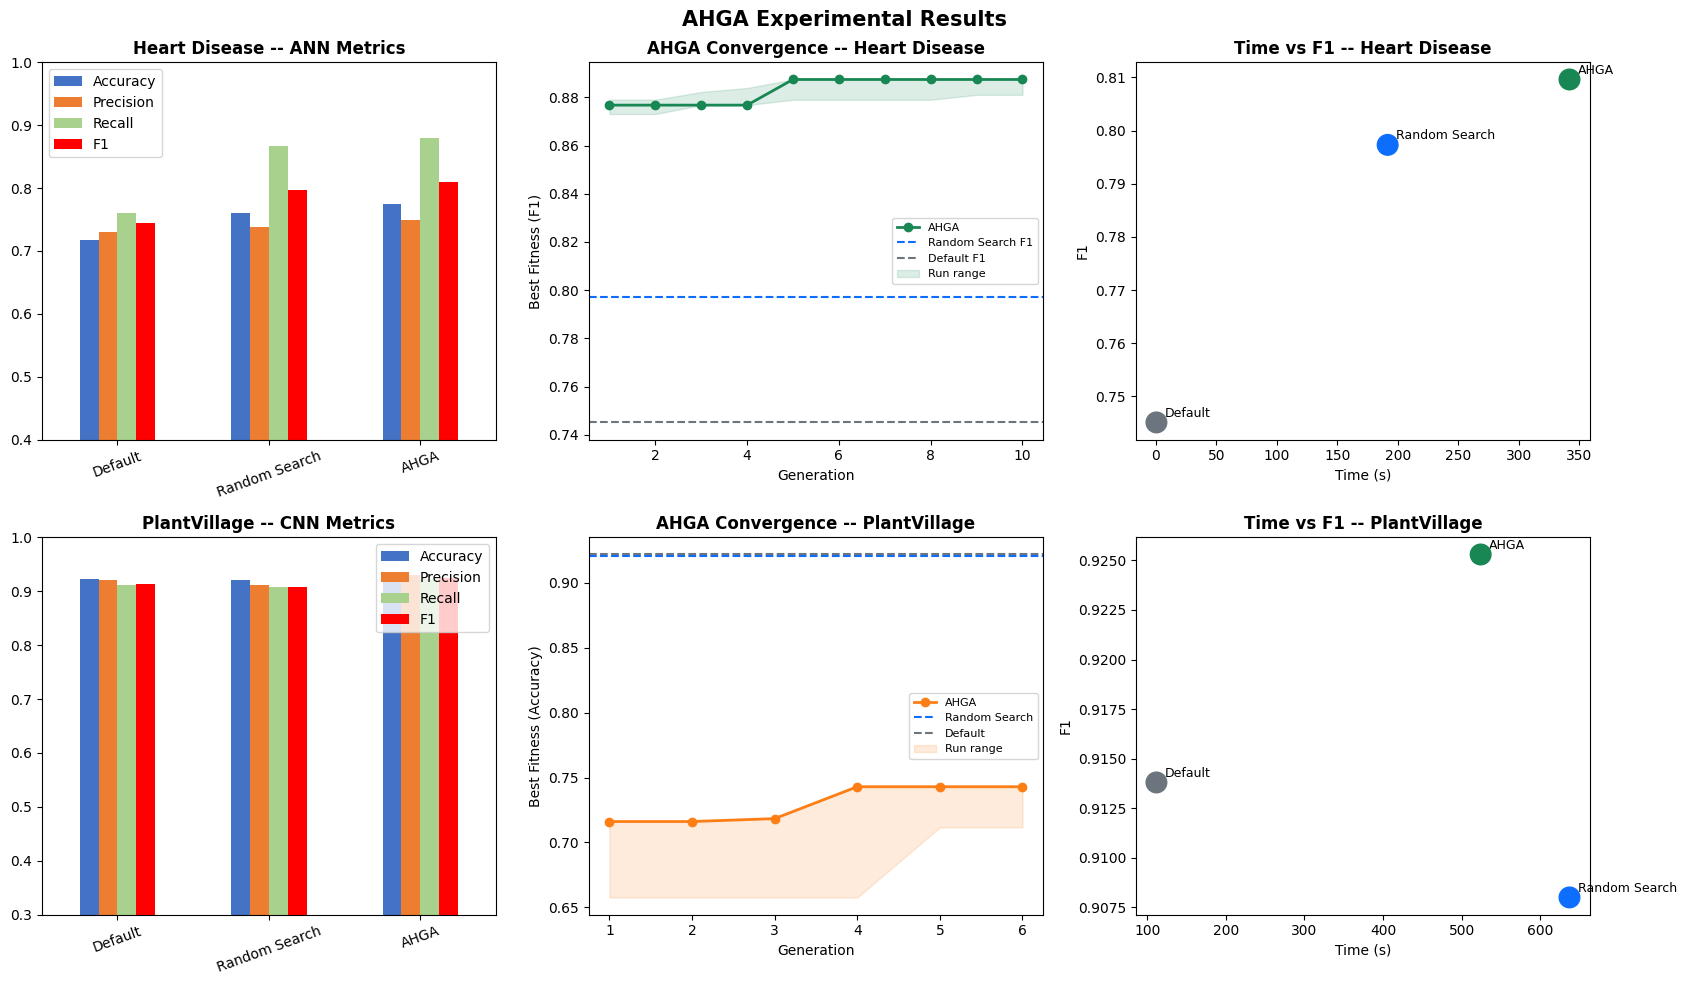

Saved: ahga_results.png


In [23]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
palette, bar_colors = ['#6c757d', '#0d6efd', '#198754'], ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('AHGA Experimental Results', fontsize=15, fontweight='bold')

ax = axes[0, 0]
df_ann.set_index('Method')[metrics_list].plot(kind='bar', ax=ax, color=bar_colors, rot=20, legend=True)
ax.set_title('Heart Disease -- ANN Metrics', fontweight='bold'); ax.set_ylim(0.4, 1.0); ax.set_xlabel('')

ax = axes[0, 1]
all_ann_hists = np.array(ann_hist_list)
ax.plot(range(1, len(ann_hist) + 1), ann_hist, 'o-', color='#198754', lw=2, label='AHGA')
ax.axhline(ann_results['Random Search']['F1'], color='#0d6efd', ls='--', label='Random Search F1')
ax.axhline(ann_results['Default']['F1'], color='#6c757d', ls='--', label='Default F1')
ax.fill_between(range(1, len(ann_hist) + 1), all_ann_hists.min(0), all_ann_hists.max(0), alpha=0.15, color='#198754', label='Run range')
ax.set_title('AHGA Convergence -- Heart Disease', fontweight='bold')
ax.set_xlabel('Generation'); ax.set_ylabel('Best Fitness (F1)'); ax.legend(fontsize=8)

ax = axes[0, 2]
methods_a = list(ann_results.keys())
times_a, f1s_a = [ann_results[m]['Time'] for m in methods_a], [ann_results[m]['F1'] for m in methods_a]
ax.scatter(times_a, f1s_a, c=palette, s=220, zorder=5)
for i, m in enumerate(methods_a):
    ax.annotate(m, (times_a[i], f1s_a[i]), textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_title('Time vs F1 -- Heart Disease', fontweight='bold'); ax.set_xlabel('Time (s)'); ax.set_ylabel('F1')

ax = axes[1, 0]
df_cnn.set_index('Method')[metrics_list].plot(kind='bar', ax=ax, color=bar_colors, rot=20, legend=True)
ax.set_title(f'{DATASET_LABEL} -- CNN Metrics', fontweight='bold'); ax.set_ylim(0.3, 1.0); ax.set_xlabel('')

ax = axes[1, 1]
all_cnn_hists = np.array(cnn_hist_list)
ax.plot(range(1, len(cnn_hist) + 1), cnn_hist, 'o-', color='#fd7e14', lw=2, label='AHGA')
ax.axhline(cnn_results['Random Search']['Accuracy'], color='#0d6efd', ls='--', label='Random Search')
ax.axhline(cnn_results['Default']['Accuracy'], color='#6c757d', ls='--', label='Default')
ax.fill_between(range(1, len(cnn_hist) + 1), all_cnn_hists.min(0), all_cnn_hists.max(0), alpha=0.15, color='#fd7e14', label='Run range')
ax.set_title(f'AHGA Convergence -- {DATASET_LABEL}', fontweight='bold')
ax.set_xlabel('Generation'); ax.set_ylabel('Best Fitness (Accuracy)'); ax.legend(fontsize=8)

ax = axes[1, 2]
methods_c = list(cnn_results.keys())
times_c, f1s_c = [cnn_results[m]['Time'] for m in methods_c], [cnn_results[m]['F1'] for m in methods_c]
ax.scatter(times_c, f1s_c, c=palette, s=220, zorder=5)
for i, m in enumerate(methods_c):
    ax.annotate(m, (times_c[i], f1s_c[i]), textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_title(f'Time vs F1 -- {DATASET_LABEL}', fontweight='bold'); ax.set_xlabel('Time (s)'); ax.set_ylabel('F1')

plt.tight_layout(); plt.savefig('ahga_results.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: ahga_results.png')

## 6. Cross-Domain Convergence Comparison

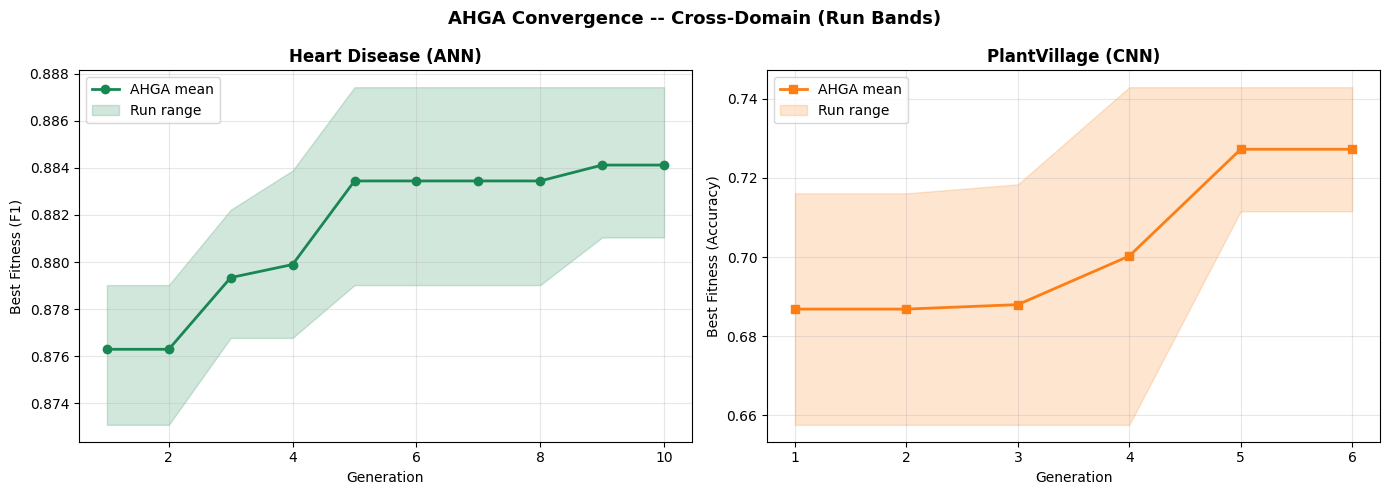

Saved: ahga_convergence.png


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AHGA Convergence -- Cross-Domain (Run Bands)', fontweight='bold', fontsize=13)

gens_a = range(1, all_ann_hists.shape[1] + 1)
ax1.plot(gens_a, all_ann_hists.mean(0), 'o-', color='#198754', lw=2, label='AHGA mean')
ax1.fill_between(gens_a, all_ann_hists.min(0), all_ann_hists.max(0), alpha=0.2, color='#198754', label='Run range')
ax1.set_title('Heart Disease (ANN)', fontweight='bold'); ax1.set_xlabel('Generation'); ax1.set_ylabel('Best Fitness (F1)')
ax1.legend(); ax1.grid(alpha=0.3)

gens_c = range(1, all_cnn_hists.shape[1] + 1)
ax2.plot(gens_c, all_cnn_hists.mean(0), 's-', color='#fd7e14', lw=2, label='AHGA mean')
ax2.fill_between(gens_c, all_cnn_hists.min(0), all_cnn_hists.max(0), alpha=0.2, color='#fd7e14', label='Run range')
ax2.set_title(f'{DATASET_LABEL} (CNN)', fontweight='bold'); ax2.set_xlabel('Generation'); ax2.set_ylabel('Best Fitness (Accuracy)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('ahga_convergence.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: ahga_convergence.png')

## 7. Combined Summary Table

In [25]:
df_ann_s = df_ann.copy(); df_ann_s['Dataset'] = 'Heart Disease (ANN)'
df_cnn_s = df_cnn.copy(); df_cnn_s['Dataset'] = f'{DATASET_LABEL} (CNN)'
summary = pd.concat([df_ann_s, df_cnn_s], ignore_index=True).set_index(['Dataset', 'Method'])

display(
    summary[['Accuracy', 'Precision', 'Recall', 'F1', 'Time']]
    .style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1'], color='#d4edda')
    .highlight_min(subset=['Time'], color='#fff3cd').format(precision=4)
)

## 8. Statistical Validity & Significance Testing

In [26]:
print('=' * 60, '\nSTATISTICAL SUMMARY (mean +/- std across repeated runs)\n' + '=' * 60)

print(f'\nHeart Disease (ANN):')
print(f'  Random Search -- Accuracy: {np.mean(rs_ann_acc):.4f} +/- {np.std(rs_ann_acc):.4f} | F1: {np.mean(rs_ann_f1):.4f} +/- {np.std(rs_ann_f1):.4f}  (n={N_RS_RUNS_ANN})')
print(f'  AHGA          -- Accuracy: {np.mean(ahga_run_accs):.4f} +/- {np.std(ahga_run_accs):.4f} | F1: {np.mean(ahga_run_f1s):.4f} +/- {np.std(ahga_run_f1s):.4f}  (n={N_AHGA_RUNS_ANN})')
print(f'  t-test (F1)   : t={ann_ttest_f1.statistic:.3f}, p={ann_ttest_f1.pvalue:.4f}')
print(f'  Grid-search ground truth F1: {grid_best_f:.4f}  (AHGA reached {best_overall_f/grid_best_f*100:.1f}% of it)')

print(f'\n{DATASET_LABEL} (CNN):')
print(f'  Random Search -- Accuracy: {np.mean(rs_cnn_acc):.4f} +/- {np.std(rs_cnn_acc):.4f} | F1: {np.mean(rs_cnn_f1):.4f} +/- {np.std(rs_cnn_f1):.4f}  (n={N_RS_RUNS_CNN})')
print(f'  AHGA          -- Accuracy: {np.mean(ahga_cnn_acc):.4f} +/- {np.std(ahga_cnn_acc):.4f} | F1: {np.mean(ahga_cnn_f1):.4f} +/- {np.std(ahga_cnn_f1):.4f}  (n={N_AHGA_RUNS_CNN})')
print(f'  t-test (Acc)  : t={cnn_ttest_acc.statistic:.3f}, p={cnn_ttest_acc.pvalue:.4f}')
print(f'  (no grid-search ground truth for CNN -- stated scope limitation, not run at this compute budget)')

print('\nCaveat to say out loud in the presentation: n=2-3 repeats per method is a small sample for a t-test.')
print('Treat the p-values as a directional signal, not proof -- be upfront about this if asked.')

STATISTICAL SUMMARY (mean +/- std across repeated runs)

Heart Disease (ANN):
  Random Search -- Accuracy: 0.7608 +/- 0.0307 | F1: 0.7973 +/- 0.0276  (n=3)
  AHGA          -- Accuracy: 0.7754 +/- 0.0205 | F1: 0.8096 +/- 0.0192  (n=3)
  t-test (F1)   : t=0.517, p=0.6322
  Grid-search ground truth F1: 0.8874  (AHGA reached 100.0% of it)

PlantVillage (CNN):
  Random Search -- Accuracy: 0.9206 +/- 0.0013 | F1: 0.9080 +/- 0.0017  (n=2)
  AHGA          -- Accuracy: 0.9364 +/- 0.0032 | F1: 0.9253 +/- 0.0053  (n=2)
  t-test (Acc)  : t=-1.214, p=0.3486
  (no grid-search ground truth for CNN -- stated scope limitation, not run at this compute budget)

Caveat to say out loud in the presentation: n=2-3 repeats per method is a small sample for a t-test.
Treat the p-values as a directional signal, not proof -- be upfront about this if asked.


## 9. Full Classification Reports -- Best Models

In [27]:
print('=== Heart Disease -- AHGA Best Model ===')
print(classification_report(yte, best_ann_model.predict(Xte), target_names=['No Disease', 'Disease']))

print(f'\n=== {DATASET_LABEL} -- AHGA Best CNN ===')
te_ld = DataLoader(te_set, batch_size=256, num_workers=2, pin_memory=(DEVICE == 'cuda'))
best_cnn_model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in te_ld:
        preds += best_cnn_model(xb.to(DEVICE)).argmax(1).cpu().tolist(); trues += yb.tolist()
print(classification_report(trues, preds, target_names=base_ds.classes))

=== Heart Disease -- AHGA Best Model ===
              precision    recall  f1-score   support

  No Disease       0.81      0.62      0.70        21
     Disease       0.73      0.88      0.80        25

    accuracy                           0.76        46
   macro avg       0.77      0.75      0.75        46
weighted avg       0.77      0.76      0.76        46


=== PlantVillage -- AHGA Best CNN ===
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.84      0.96      0.90       149
                     Pepper__bell___healthy       0.96      0.99      0.97       221
                      Potato___Early_blight       0.95      0.93      0.94       150
                       Potato___Late_blight       0.92      0.89      0.90       150
                           Potato___healthy       0.86      0.78      0.82        23
                      Tomato_Bacterial_spot       0.90      0.98      0.94       3